## **Environment Setup (Local or Google Colab)**

The code block below automatically detects your execution runtime environment (Local vs. Google Colab), clones the repository, and installs all necessary dependencies.

> **Google Colab Note:** Once setup completes, navigate to **Runtime → Restart session** in the top menu before proceeding to the next steps to ensure all newly installed packages are correctly loaded.

In [1]:
import os
import subprocess
import sys

# Environment Detection: Check sys.modules for Colab runtime
IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    print("Detected Google Colab environment. Initializing setup...")

    # Define paths
    branch = "dev-ch3"
    repo_url = (
        "https://github.com/paymantohidifar/deep-learning-for-biology-book.git"
    )
    target_dir = "/content/dlfb"

    # Clean stale builds and clone main branch
    subprocess.run(f"rm -rf {target_dir}", shell=True, check=True)
    subprocess.run(
        f"git clone {repo_url} --branch {branch} {target_dir}",
        shell=True,
        check=True,
    )
    print("Cloned the repo.")

    # Change working directory
    os.chdir(target_dir)

    # Bootstrap uv and install dependencies into system environment
    install_cmd = (
        'curl -LsSf https://astral.sh/uv/install.sh | sh && '
        'export PATH="$HOME/.local/bin:${PATH}" && '
        'uv pip install -e .[gpu] --system --break-system-packages --color never'
    )
    print("Installing dependencies...")
    subprocess.run(install_cmd, shell=True, check=True)
    print("Colab setup complete.")

    # Download chapter data
    print("Downloading chapter data ...")
    subprocess.run(
        "dlfb-provision --chapter dna",
        shell=True,
        check=True,
    )
    print("Downloading data complete.")
else:
    # Local Development: Enable IPython Auto-Reload safely
    ipython = get_ipython()
    if ipython is not None:
        ipython.run_line_magic("load_ext", "autoreload")
        ipython.run_line_magic("autoreload", "2")
        print("Enabled IPython autoreload.")

    # Download chapter data
    print("Downloading chapter data ...")
    subprocess.run(
        "dlfb-provision --chapter dna --destination ../data",
        shell=True,
        check=True,
    )
    print("Downloading data complete.")

Enabled IPython autoreload.


Files Downloaded:  73%|███████▎  | 192/264 [00:01<00:00, 236.68file/s]

Files Downloaded: 100%|██████████| 264/264 [00:01<00:00, 201.36file/s]


## **Load the `dlfb` package**  

Load the `dlfb` package.

**Note:** Loading can sometimes be finicky. If you encounter issues, simply **restart the runtime**. All previously downloaded data and installed packages will persist, so you can re-run the load step without repeating everything.

In [2]:
# Toggle JAX_DISABLE_JIT to True for easier debugging
%env JAX_DISABLE_JIT=False

try:
  import dlfb
except ImportError as exc:
  # NOTE: Packages installed in editable mode are not immediately
  #       recognized by Colab (https://stackoverflow.com/a/63312333).
  import site
  site.main()
  import dlfb

from dlfb.utils.display import display

env: JAX_DISABLE_JIT=False


## **Verify Packages**  

In [3]:
from importlib.metadata import version

required_pkgs = [
    "pandas",
    "numpy",
    "tensorflow",
]
for pkg in required_pkgs:
    print(f"{pkg}: {version(pkg)}")

pandas: 2.2.2
numpy: 2.1.2
tensorflow: 2.19.0


---

# **Chapter 3: Learning the Logic of DNA**

In this chapter, we will build and train deep learning models from scratch to predict whether DNA sequences are bound by transcription factors (TFs). Unlike the previous chapter, we will define our own architectures, specifically convolutional neural networks (CNNs) and transformers, to decode genomic regulatory logic.

The project follows a three-stage roadmap:
* **Simple Prototype:** Training a basic CNN to predict the binding of a single transcription factor, CTCF.
* **Increased Complexity:** Scaling up to 10 different TFs while introducing regularization, normalization, and interpretability techniques like in silico mutagenesis and input gradients.
* **Advanced Techniques:** Incorporating transformer layers to capture long-range dependencies and analyzing how these architectural choices impact learning.

This staged approach is designed to build confidence while ensuring the models remain debuggable and interpretable. 

---

## **Table of Contents**

---

## **Biology Primer**

DNA consists of four chemical bases (A, C, G, T) that carry the genetic instructions for building a human body across a 3.2-billion-base-pair genome. While only 2% of the genome codes for proteins, the remaining 98% is noncoding DNA that performs critical regulatory roles, such as serving as docking sites for regulatory proteins. These proteins, known as **transcription factors (TFs)**, act as conductors that control gene activity by binding to short, specific DNA sequences called **motifs**. 

Not every matching motif is actually bound in a living cell. In fact, the genome contains far more motif matches than actual binding events. That’s because
binding depends on many additional factors:

**Chromatin accessibility**: DNA that’s tightly packed into chromatin is harder for proteins to access. TFs are more likely to bind in regions of open chromatin.

**DNA methylation**: Certain TFs, like CTCF, are sensitive to methylation (a certain chemical modification of DNA bases) at their binding sites, which can block binding even if the motif is present.

**Cellular signals**: Signals inside the cell, such as hormones or stress responses, can activate or deactivate a TF’s ability to bind.
    
**Other proteins**: Helper or blocking proteins in the local environment can facilitate or inhibit binding.

**Cooperative binding**: Many TFs work in complexes or recruit others to stabilize binding and control gene activity.

And perhaps most importantly, real cells are dynamic. Molecules move, concentrations change, and TF binding events happen on short timescales. Most genomic datasets, by contrast, are static snapshots, freeze-frames of a constantly changing scene. That’s worth keeping in mind when interpreting binding data in this chapter.

Researchers use a laboratory technique called **ChIP-seq** to capture snapshots of these binding events, which are then simplified into binary labels (bound or not bound) for deep learning models to learn. This biological foundation is what our models will attempt to decode.

---

## **Machine Learning Primer**

This section briefly cover convolutional and transformer-based architectures, how they can be applied to biological sequence data like DNA, and what kinds of insights they can provide.

### **Convolutional Neural Networks**

Convolutional Neural Networks (CNNs) were originally developed for image recognition tasks. In images, low-level features like edges and textures appear in small local patches, while higher-level
concepts like shapes or objects are formed by combining these local features. CNNs mirror this structure by using small, learnable filters that slide across the input, extracting local patterns at each position. As we stack more layers, the model combines local features into more abstract and global representations.

Their core strength lies in their ability to automatically learn useful patterns from raw, grid-like input data, whether that’s pixels in an image or bases in a DNA sequence, without the need for hand-engineered features.

#### **Core Mechanisms and Components**

* **Filters (Kernels):** These are small learnable weight matrices that "slide" across the input sequence to perform dot product operations. They act as pattern detectors, producing feature maps that highlight where specific motifs occur.
* **Pooling Layers:** These layers downsample feature maps to reduce computational load and dimensionality. Max pooling, for instance, retains only the strongest signal in a region, helping the model focus on the most salient biological features.
* **Normalization:** Layers like batch normalization rescale activations to reduce internal covariate shift, making training more stable and accelerating convergence.
* **Fully Connected Layers:** Located at the end of the network, these layers use the extracted features to make final predictions, such as determining if a sequence is bound by a transcription factor.

### **Convolutions for DNA Sequences**

CNNs have become a standard architecture for biological sequence data because they automatically learn hierarchical patterns directly from raw inputs, such as the bases in a DNA sequence.

#### **Importance for DNA Analysis**

* **Translation Equivariance:** This is a critical property for genomics; it ensures that a binding motif is recognized regardless of its specific position (e.g., index 10 or 90) within the DNA sequence.
* **1D Convolutions:** While CNNs were popularized for 2D images, genomics uses 1D filters applied to one-hot encoded DNA matrices (where A, C, G, and T are represented as binary vectors). 
* **Hierarchical Learning:** Shallow layers typically detect simple low-level features like GC-rich regions, while deeper layers identify high-order combinations and complex motifs.

#### **Strengths and Limitations**

CNNs offer an excellent balance of power, speed, and interpretability, as researchers can visualize exactly which motifs a specific filter has learned to detect. However, they are limited by their fixed window size, which makes it difficult for them to model long-range dependencies between elements located far apart on the genome. This is where we turn to a different class of models such as transformers.

### **Transformers**

Transformers are powerful for DNA analysis because their self-attention mechanism can capture long-range dependencies between motifs that are far apart in a sequence. Self-Attention allows each position in a sequence to dynamically focus on every other position to determine relevance. It enriches each token's embedding with global contextual information.

While transformers excel at modeling complex relationships that CNNs struggle with, their computational cost grows quadratically with sequence length, which can be a bottleneck for very long genomic inputs.

### **Attention**

The Attention mechanism is the core of the transformer architecture, allowing the model to enrich each token's embedding with information from every other token in a sequence, making them "context-aware".

#### **The Mechanism: Queries, Keys, and Values**

The model transforms input embeddings into three distinct perspectives through learned linear transformations:
* **Queries (Q):** Define what a token is "looking for" (e.g., a specific upstream motif).
* **Keys (K):** Advertise what information a token "contains".
* **Values (V):** Provide the actual content passed along if a Query matches a Key.

By comparing Queries to all Keys using a dot product, the model generates attention weights (via scaled softmax) that determine how much of each Value vector is summed into the token’s new representation.

#### **Biological Significance**

In genomics, this allows the model to integrate signals across arbitrary distances, such as determining if a regulatory motif is influenced by an element thousands of bases away. This "smart lookup system" enables the model to learn complex, long-range dependencies that fixed-size convolutional windows might miss.

### **Query, Key and Value Intuition**

The Query, Key, and Value (Q, K, V) projections allow the model to treat a sequence as a "smart lookup system," where each token views the data from different perspectives:

* **Query (Q):** Acts as a "lens" for a token to express what information it is looking for (e.g., a specific motif).
* **Key (K):** Acts as an **advertisement** of what content a token contains.
* **Value (V):** The **actual content** that is passed along when a Query successfully matches a Key.

By separating these roles, the model doesn't treat all parts of a sequence as equally relevant; instead, each token pulls a weighted mixture of Values based on how well its Query matched the others' Keys. These projections are not fixed but are learned from data during training.

### **Multiheaded Attention**

Multiheaded Attention (MHA) enhances the transformer's ability to process complex sequences by running several attention operations, or "heads," in parallel. 

* **Diverse Perspectives:** Each head can focus on different scales or patterns simultaneously, for example, one head might detect a local binding motif while another identifies long-range interactions thousands of bases away.
* **Integration:** The outputs from all heads are concatenated and linearly transformed to produce a final representation that is richer and more expressive than a single attention operation could achieve.
* **Biological Utility:** This parallel structure is specifically useful for biological sequences where various signals and dependencies exist at different scales.

### **Representing Positional Information**

Self-attention is inherently **position invariant**, meaning it cannot distinguish the order or position of bases on its own. To address this, Transformer models typically use positional encodings, such as sinusoidal functions of the token index, to inject information about sequence order.

In the specific model built in this chapter, the authors omit explicit positional encodings as a simplification. They suggest that for short 200 bp sequences, the convolutional layers preceding the attention block can sufficiently capture the relative arrangement of motifs.

### **Model Interpretation**

Model interpretation techniques help peek inside the "black box" of deep learning to understand how models make specific biological predictions. The chapter focuses on two primary methods for generating "saliency maps" that highlight influential DNA regions:

* **In Silico Saturation Mutagenesis (ISM)**: This method involves systematically mutating every base in a sequence to all other possible bases and recording the change in the model's output. While computationally expensive due to the high number of forward passes required, it is highly intuitive and provides direct evidence of which motifs are critical for binding.
* **Input Gradients**: This is a much faster, mathematical alternative that computes the derivative of the model's prediction with respect to the input. It measures the model's sensitivity to tiny perturbations at each position. Unlike ISM, gradients represent "directional sensitivity" rather than discrete substitutions, which can sometimes make them noisier or harder to interpret.
* **Attention Mechanisms**: For models using transformer layers, researchers can inspect attention weights to visualize which parts of a sequence the model is focusing on to integrate global context.

### **In Silico Saturation Mutagenesis**

In Silico Saturation Mutagenesis (ISM) is an interpretation technique used to identify which parts of a biological sequence are most important for a model's prediction.

The process involves systematically changing every base in a sequence to the other three possible bases and recording how each mutation affects the model's output. It produces a **saliency map** (often visualized as a heatmap) that highlights critical regions, such as binding motifs. If mutating a specific base significantly drops the predicted binding probability, that base is deemed essential for the model's decision.

**Pros and Cons**: ISM is highly intuitive and provides direct evidence of a motif's importance. However, it is computationally expensive because it requires a separate model forward pass for every possible mutation at every position.

<figure style="text-align: center; width: 750px; margin: 0 auto;">
    <img src="./images/figure_3_4.png" width=100%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>Figure 3.4</strong> Example of an in silico saturation mutagenesis plot showing predicted probabilities of transcription factor binding across a 200-base DNA sequence. The x-axis represents the DNA sequence positions, while the y-axis shows the three possible mutations at each position (including the mutation to the original base, which has no effect and is set to zero). In this example, most mutation effects are negative (darker color), indicating that changing bases generally reduces the predicted binding probability. This approach is computationally expensive due to the large number of forward passes required to generate this output matrix (here, 3 mutations × 200 positions = 600 model predictions).
    </figcaption>
</figure>

### **Input Gradients**

Input gradients serve as a fast, mathematical alternative to in silico mutagenesis for identifying influential regions in a DNA sequence. 

This technique computes the derivative of the model's output with respect to each input base, measuring how sensitive a prediction is to tiny, infinitesimal perturbations at every position. Unlike mutagenesis, gradients do not simulate actual base changes. Instead, they reflect "directional sensitivity," meaning even a base already present in the sequence can show a high gradient if the model relies heavily on it for its decision. A large gradient suggests that the base at that position has a significant influence on the prediction (e.g., a binding event), while low gradients indicate regions the model considers less important.

**Pros and Cons**: Gradients are highly computationally efficient, requiring only a single backward pass to generate an entire importance map. However, the resulting maps can be noisier and harder to interpret than those from mutagenesis due to model nonlinearities or saturation effects.

---

## **Building a Simple Prototype**

The prototype's goal is a binary classification task: predicting whether a 200-base DNA sequence binds to the transcription factor **CTCF**. CTCF is an ideal starting point because its binding behavior is highly predictable, thanks to a well-characterized and conserved motif with strong sequence specificity. 

Biologically, CTCF plays a key role in organizing the genome's 3D architecture by folding DNA into loops and domains that regulate gene activity. This staged approach allows for building a solid foundation before iteratively scaling to predict binding for 10 different TFs using more complex architectures.

### **Building a Dataset**

#### **Loading the Labeled Sequences**

In [4]:
import pandas as pd

from dlfb.utils.context import assets

train_df = pd.read_csv(assets("dna/datasets/CTCF_train_sequences.csv"))
print(train_df)

                                                sequence  label  \
0      TACCACATGAGTTCTCTTTCAGTTTGCTATGGAAGACACAAAAACC...      1   
1      CATCAACACTCGTGCGACGCCCTCGCATTTTCATTAATGATGGCCT...      0   
2      GCACACAGCGCAGGAACCTGGCACTGGAGAAGCCACCCAGGCTGTG...      1   
3      GCCAGCCGAAGCAGAGAGCAGTGCACATGCGTGCAGCTACCAGCAT...      1   
4      GTCCCGTCCCTTTTCGTGCCTCTGCCCCCACAGCTGCTGCAGTCTG...      1   
...                                                  ...    ...   
61078  AATATGACCCTGCTGGCCTTAGGCCTACTCCTGTACCACAAGTGCC...      0   
61079  GATAAACCAAGGTCGTAAGTTCAGGCTCCGCCTCCCCGCAGGGCCT...      1   
61080  CCTCCCTCCCATCCCCCACACAGTTTAATGTCTAGAAGGTTGCCTG...      1   
61081  CAGGAATGCACCGGAAGTCCGCCTCCCGGGACCCGCCGCCGGTCCC...      0   
61082  AAAACAGAAACTGAAACTTCAAACACAGAGACAGAAAAAAAAAAAA...      0   

      transcription_factor subset  
0                     CTCF  train  
1                     CTCF  train  
2                     CTCF  train  
3                     CTCF  train  
4              

Let's look at the class distribution:

In [5]:
train_df["label"].value_counts()

label
1    30545
0    30538
Name: count, dtype: int64

The two classes appear fairly balanced (equally represented) in the training dataset, so we won’t have to do any rebalancing by downsampling the majority class here.

To use the DNA sequences numerically, we need to convert them into one-hot format. The function `dna_to_one_hot` performs this mapping:

```python
def dna_to_one_hot(dna_sequence: str) -> np.ndarray:
    """Convert DNA into a one-hot encoded format with channel ordering ACGT."""
    base_to_one_hot = {
      "A": (1, 0, 0, 0),
      "C": (0, 1, 0, 0),
      "G": (0, 0, 1, 0),
      "T": (0, 0, 0, 1),
      "N": (1, 1, 1, 1),  # N represents any unknown or ambiguous base.
    }
    one_hot_encoded = np.array([base_to_one_hot[base] for base in dna_sequence])
    return one_hot_encoded

  ```

In [6]:
from dlfb.dna.utils import dna_to_one_hot

# display(["import numpy as np", dna_to_one_hot])

In [7]:
# Example test
dna_to_one_hot("AAACGT")

array([[1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 1]])

We can apply this converter to the entire training dataset to generate the numerical training data x_train as follows:

In [8]:
import numpy as np

x_train = np.array([dna_to_one_hot(seq) for seq in train_df["sequence"]])
y_train = train_df["label"].values[:, None]

Here, `y_train` contains the binary target labels: **0** means the sequence does not bind CTCF, and **1** means the sequence does bind CTCF.

In [9]:
print(y_train)

[[1]
 [0]
 [1]
 ...
 [1]
 [0]
 [0]]


We can wrap two lines of code above into the `load_dataset` function:

```python
def load_dataset(sequence_db) -> dict[str, np.ndarray]:
    """Load sequences and labels from a CSV into numpy arrays."""
    df = pd.read_csv(sequence_db)
    return {
        "labels": df["label"].to_numpy()[:, None],
        "sequences": np.array([dna_to_one_hot(seq) for seq in df["sequence"]]),
        }
```

#### **Convert the Data to a TensorFlow Dataset**

Next, we convert the training data into a TensorFlow dataset using the `convert_to_tfds` function. This format makes it easy to efficiently iterate over batches during model training, especially when shuffling and repeating the data for multiple epochs:

```python
def convert_to_tfds(
    dataset,
    batch_size: int | None = None,
    is_training: bool = False
    ) -> tf.data.Datset:
    """Convert DNA sequences and labels to a TensorFlow dataset."""
    ds = tf.data.Dataset.from_tensor_slices(dataset)
    if is_training:
        ds = ds.shuffle(buffer_size=len(dataset["sequences"]))
        ds = ds.repeat()
    batch_size = batch_size or len(dataset["labels"])
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.experimental.AUTOTUNE) # Prepare the upcoming batch on cpu ready to be fed to GPU/TPU
    return ds

```

We then create the training dataset `train_ds` with batching, shuffling, and repetition enabled:

In [13]:
from dlfb.dna.dataset import load_dataset
from dlfb.dna.dataset import convert_to_tfds

# display([convert_to_tfds])

batch_size = 32

train_ds = convert_to_tfds(
    load_dataset(assets("dna/datasets/CTCF_train_sequences.csv")),
    batch_size=batch_size,
    is_training=True,
)

2026-08-19 20:35:03.985523: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787196904.066988   11074 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787196904.089841   11074 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787196904.275559   11074 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787196904.275581   11074 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787196904.275583   11074 computation_placer.cc:177] computation placer alr

Let’s sanity-check by pulling one batch from the dataset and inspecting its shape and contents:

In [14]:
batch = next(train_ds.as_numpy_iterator())
print(f'Batch sequence shape: {batch["sequences"].shape}')
print(f'Batch sequence instances: {batch["sequences"][:3,:3,]}...')
print(f'Batch labels shape: {batch["labels"].shape}')
print(f'Batch labels instances: {batch["labels"][:3,]}...')

Batch sequence shape: (32, 200, 4)
Batch sequence instances: [[[0 1 0 0]
  [1 0 0 0]
  [0 1 0 0]]

 [[0 0 0 1]
  [0 1 0 0]
  [1 0 0 0]]

 [[0 0 1 0]
  [0 0 1 0]
  [1 0 0 0]]]...
Batch labels shape: (32, 1)
Batch labels instances: [[1]
 [1]
 [0]]...


This looks sensible. We see the data has shape (32, 200, 4), indicating a batch size of 32, sequence length of 200, and 4 channels per DNA base as expected. The labels have shape (32, 1) since each label is a simple binary 0 or 1.

For validation, since the dataset is smaller, we can structure it as one single big batch:

In [ ]:
valid_ds = load_dataset(assets("dna/datasets/CTCF_valid_sequences.csv"))

In [17]:
print(len(valid_ds["labels"]))
print(valid_ds['sequences'][0].shape)

8726
(200, 4)


With our data now in the correct format, we are ready to build and train our first simple model.

### **Defining a Simple Convolutional Model**

Next, we define a simple CNN composed of two 1D convolutional layers, followed by flattening and fully connected (dense) layers:

```python
class ConvModel(nn.Module):
  """Basic CNN model for binary sequence classification."""

  conv_filters: int = 64  # Number of filters for conv layers.
  kernel_size: tuple[int] = (10,)  # Kernel size for 1D conv layers.
  dense_units: int = 128  # Units in first dense fully-connected layer.

  @nn.compact
  def __call__(self, x):
    # First convolutional layer.
    x = nn.Conv(
      features=self.conv_filters, kernel_size=self.kernel_size, padding="SAME"
    )(x)
    x = nn.gelu(x)
    x = nn.max_pool(x, window_shape=(2,), strides=(2,))

    # Second convolutional layer.
    x = nn.Conv(
      features=self.conv_filters, kernel_size=self.kernel_size, padding="SAME"
    )(x)
    x = nn.gelu(x)
    x = nn.max_pool(x, window_shape=(2,), strides=(2,))

    # Flatten the values before passing them to the dense layers.
    x = x.reshape((x.shape[0], -1))

    # First dense layer.
    x = nn.Dense(self.dense_units)(x)
    x = nn.gelu(x)

    # Second dense layer.
    x = nn.Dense(self.dense_units // 2)(x)
    x = nn.gelu(x)

    # Output layer (single unit for binary classification).
    return nn.Dense(1)(x)

  def create_train_state(self, rng, dummy_input, tx) -> TrainState:
    """Initializes model parameters and returns a train state for training."""
    rng, rng_init = jax.random.split(rng)
    variables = self.init(rng_init, dummy_input)
    state = TrainState.create(
      apply_fn=self.apply, params=variables["params"], tx=tx
    )
    return state

```

Here is the schematic of the model we defined above:

<figure style="text-align: center; width: 750px; margin: 0 auto;">
    <img src="./images/1d_cnn_dnaseq.png" width=100%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>1D CNN Architecture Sketch for DNA Sequence</strong>
    </figcaption>
</figure>

In [68]:
# display([ConvModel], hide=[ConvModel.create_train_state])

This model architecture is fairly “no frills” but should already be able to capture local patterns in DNA sequences. We can instantiate our model like this:

In [19]:
from dlfb.dna.model import ConvModel

model = ConvModel()

To initialize model parameters in JAX, we need to provide a dummy input tensor that matches the expected shape of the model’s input. Although we could use an actual batch from our dataset, it is common and simpler to use a tensor of ones with batch size 1 and the same shape as a single-encoded DNA sequence. Importantly, the batch size used for this dummy input does not affect the model initialization; JAX initializes parameters based on the shape of an individual input sample (excluding the batch dimension). This means the model can later be trained or used for inference with any batch size.

In [26]:
import jax
import jax.numpy as jnp

dummy_input = jnp.ones((1, *batch["sequences"][1,].shape))
print(dummy_input.shape)

rng_init = jax.random.PRNGKey(42)
variables = model.init(rng_init, dummy_input)
params = variables["params"]

(1, 200, 4)


Understanding and keeping track of tensor shapes is a crucial part of machine learning. Always make it a habit to verify the shapes of your data as it flows through the model. So let's confirm the shape of the input tensor along the model layers by printing out the shape of `x` after every transformation:

In [ ]:
import flax.linen as nn
import jax
from flax.training.train_state import TrainState


class DummyConvModel(nn.Module):
  """Basic CNN model for binary sequence classification."""

  conv_filters: int = 64  # Number of filters for conv layers.
  kernel_size: tuple[int] = (10,)  # Kernel size for 1D conv layers.
  dense_units: int = 128  # Units in first dense fully-connected layer.

  @nn.compact
  def __call__(self, x):
    # First convolutional layer.
    print("Input shape:", x.shape)
    x = nn.Conv(
      features=self.conv_filters, kernel_size=self.kernel_size, padding="SAME"
    )(x)
    print("Conv_1 shape:", x.shape)
    x = nn.gelu(x)
    x = nn.max_pool(x, window_shape=(2,), strides=(2,))
    print("MP_1 shape:", x.shape)

    # Second convolutional layer.
    x = nn.Conv(
      features=self.conv_filters, kernel_size=self.kernel_size, padding="SAME"
    )(x)
    print("Conv_2 shape:", x.shape)
    x = nn.gelu(x)
    x = nn.max_pool(x, window_shape=(2,), strides=(2,))
    print("MP_2 shape:", x.shape)

    # Flatten the values before passing them to the dense layers.
    x = x.reshape((x.shape[0], -1))
    print("Flatten:", x.shape)

    # First dense layer.
    x = nn.Dense(self.dense_units)(x)
    x = nn.gelu(x)
    print("Dense_1:", x.shape)

    # Second dense layer.
    x = nn.Dense(self.dense_units // 2)(x)
    x = nn.gelu(x)
    print("Dense_2:", x.shape)

    # Output layer (single unit for binary classification).
    return nn.Dense(1)(x)

  def create_train_state(self, rng, dummy_input, tx) -> TrainState:
    """Initializes model parameters and returns a train state for training."""
    rng, rng_init = jax.random.split(rng)
    variables = self.init(rng_init, dummy_input)
    state = TrainState.create(
      apply_fn=self.apply, params=variables["params"], tx=tx
    )
    return state

dummy_model = DummyConvModel()
_ = dummy_model.init(rng_init, dummy_input)

Input shape: (1, 200, 4)
Conv_1 shape: (1, 200, 64)
MP_1 shape: (1, 100, 64)
Conv_2 shape: (1, 100, 64)
MP_2 shape: (1, 50, 64)
Flatten: (1, 3200)
Dense_1: (1, 128)
Dense_2: (1, 64)


#### **Examining Model Tensor Shapes**

Here are some key operations in the model that change tensor shapes:

* **Convolutional layers (`nn.Conv`):** These layers can modify the channel dimension. For example, our input starts with four channels (DNA bases), but the first convolution increases this to 64 channels, effectively learning 64 different sequence features or motifs. Additionally, the convolution’s padding option affects the sequence length dimension:
    * `padding='SAME'` preserves the sequence length.
    * `padding='VALID'` reduces it depending on the kernel size. Try switching between these in `DummyConvModel`to see the impact on the sequence length.

* **Max pooling layers (`nn.max_pool`):** These reduce the sequence length by downsampling. In our model, each max pooling layer halves the length, from 200 to 100 and then to 50 bases. To reduce the spatial axis more aggressively (e.g., by a factor of 2 each time), adjust the `window_shape` and `strides` arguments accordingly (typically, these are set to the same value to avoid overlapping windows and simplify downsampling).

* **Flattening (reshape):** Before passing data to dense layers, the tensor is reshaped from (`batch_size, sequence_length, channels`) to (`batch_size, flattened_features`). This collapses the spatial and channel dimensions into one long vector per example, preparing it for fully connected layers.

Once the model parameters are initialized, you can inspect them to confirm the layer structure and shapes. Check the parameter keys (layer names) with:

In [30]:
params.keys()

dict_keys(['Conv_0', 'Conv_1', 'Dense_0', 'Dense_1', 'Dense_2'])

In [37]:
for layer_name in params:
    print(f'Layer {layer_name} param shape: {params[layer_name]["kernel"].shape}')

Layer Conv_0 param shape: (10, 4, 64)
Layer Conv_1 param shape: (10, 64, 64)
Layer Dense_0 param shape: (3200, 128)
Layer Dense_1 param shape: (128, 64)
Layer Dense_2 param shape: (64, 1)


Some notes on these shapes:
* For convolutional layers, the parameter shape is (`kernel_size, input_channels, output_channels`). For example, `Conv_0` has kernel size 10, input channels 4 (DNA bases), and outputs 64 feature maps.
* Dense layers have shapes (`input_features, output_units`). For instance, `Dense_0` maps 3200 flattened features ($50 \times 64$) to 128 units.

With the model initialized and the parameter shapes explored, let’s start setting up our training loop.

#### **Making Predictions with the Model**

We can actually already obtain predictions from the model using the randomly initialized parameters, though the predictions will be random. We make predictions by calling model.apply on a batch of sequences:

In [ ]:
logits = model.apply({"params": params}, batch["sequences"])

# Apply sigmoid to convert logits to probabilities.
probs = nn.sigmoid(logits)

# Print just the first few predictions.
print(probs[0:5])

[[0.48129943]
 [0.47904453]
 [0.48692954]
 [0.48184627]
 [0.5026326 ]]


Since the model is not trained yet, we can see that the predicted probabilities are around 0.5, reflecting pure guesswork from our randomly-parameterized model.

#### **Defining a Loss Function**

Let's now define a binary cross-entropy loss function using the `optax` library. We need this to be able to train our model. Note that we're predicting whether a TF binds to a given DNA sequence, a classic binary classification task. Binary cross-entropy is the standard loss function for this setting: it measures how well the model’s predicted probabilities align with the true binary labels.

In [38]:
import optax


def calculate_loss(params, batch):
    """Make predictions on batch and compute binary cross entropy loss."""
    logits = model.apply({"params": params}, batch["sequences"])
    loss = optax.sigmoid_binary_cross_entropy(logits, batch["labels"]).mean()
    return loss

In [39]:
calculate_loss(params, batch)

Array(0.6883525, dtype=float32)

This gives a baseline loss value before training. As the model learns, this loss should decrease substantially.

#### **Defining the `TrainState`**

To start training the model, we first need to define the optimizer. We’ll use **Adam** with a learning rate of **1e-3**, which is a common default value that tends to work well across diverse problems:

In [40]:
learning_rate = 0.001

tx = optax.adam(learning_rate)

With this, we now have all the components to initialize the training state. For this, we’ll use Flax’s `TrainState` class, which is a container that bundles all the important objects for training (the model, parameters, and optimizer):

In [41]:
from flax.training.train_state import TrainState

state = TrainState.create(apply_fn=model.apply, params=params, tx=tx)

For convenience, let’s define a function to create the train state:

In [43]:
def create_train_state(model, rng, dummy_input, tx) -> TrainState:
    variables = model.init(rng, dummy_input)
    state = TrainState.create(
      apply_fn=model.apply, params=variables["params"], tx=tx
    )
    return state

#### **Defining a Single Training Step**

Finally, putting everything together, we can write a function to run one training iteration, which performs these steps:

1. **Forward pass:** Takes a batch of data, makes model predictions, and computes loss based on the current parameters
2. **Backwards pass:** Computes gradients of the loss with respect to the parameters
3. **Update:** Using the computed gradients, updates the parameters to minimize the model’s loss

These steps happen in the `train_step` function:

In [45]:
@jax.jit
def train_step(state, batch):
    """Run single training step to compute gradients and update model params."""
    grad_fn = jax.value_and_grad(calculate_loss, has_aux=False)
    loss, grads = grad_fn(state.params, batch)
    state = state.apply_gradients(grads=grads)
    return state, loss

Let’s run one training step:

In [46]:
state, loss = train_step(state, batch)

If our setup is working well, the training loss should already be lower on this batch. Let’s check:

In [48]:
calculate_loss(state.params, batch)

Array(0.65560037, dtype=float32)

And indeed, the loss is lower than it was before a `train_step` was run. With the model and training loop ready, let’s set up a full training run.

#### **Training the Simple Model**

Let’s now run the preceding train_step many times in order to optimize the model. Here, we train for 500 steps and periodically evaluate on the validation set:

In [49]:
import tqdm

# Reinitialize the model state to ensure we start fresh each time cell is run.
rng_init = jax.random.PRNGKey(42)
state = create_train_state(model, rng_init, dummy_input, tx)

# Keep track of both the training and validation set losses.
train_losses, valid_losses = [], []
train_batches = train_ds.as_numpy_iterator()

# We use tqdm, which is a progress bar.
for step in tqdm.tqdm(range(500)):
    batch = next(train_batches)
    state, loss = train_step(state, batch)
    train_losses.append({"step": step, "loss": loss.item()})

    # Compute loss on the entire validation set occasionally (every 100 steps).
    if step % 100 == 0:
        valid_loss = calculate_loss(state.params, valid_ds)
        valid_losses.append({"step": step, "loss": valid_loss.item()})

losses = pd.concat(
  [
    pd.DataFrame(train_losses).assign(split="train"),
    pd.DataFrame(valid_losses).assign(split="valid"),
  ]
)

100%|██████████| 500/500 [00:17<00:00, 28.98it/s]


In [50]:
losses

,step,loss,split
0,0,0.709623,train
1,1,0.888485,train
2,2,0.748875,train
3,3,0.685022,train
4,4,0.692362,train
...,...,...,...
0,0,0.802864,valid
1,100,0.483368,valid
2,200,0.359074,valid
3,300,0.300345,valid


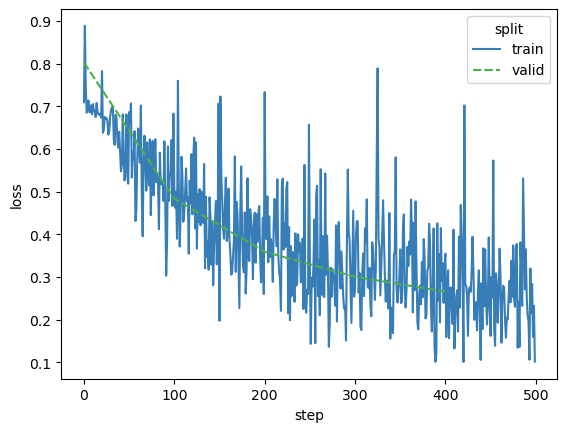

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

from dlfb.utils.metric_plots import DEFAULT_SPLIT_COLORS

sns.lineplot(
    data=losses,
    x="step",
    y="loss",
    hue="split",
    style="split",
    palette=DEFAULT_SPLIT_COLORS
);

Reaching this stage, where you have a working model, a dataset, and training with decreasing loss, is a major milestone. The rest of this chapter focuses on improving and extending this foundation.

#### **Sanity Checking the Model**

Before we do anything more complicated, we should first check that the model has learned something sensible. One simple check is verifying that the trained model
behaves as expected on known DNA motifs. For example, from an online search, we can see that the CTCF transcription factor is known to prefer binding DNA sequences containing motifs similar CCACCAGGGGGCGC. Let’s construct the 200-base-long DNA string containing repeats of this motif and convert it to the one-hot encoded format that our model expects:

In [56]:
ctcf_motif_dna = "CCACCAGGGGGCGC" * 14 + "AAAA"
print("Length of CTCF motif-filled DNA string:", len(ctcf_motif_dna))

# We add the None here as a batch axis, since our model expects batched input.
ctcf_input = dna_to_one_hot(ctcf_motif_dna)[None, :]
ctcf_input.shape

Length of CTCF motif-filled DNA string: 200


(1, 200, 4)

We expect that the model will predict a very high probability of CTCF binding this sequence, since it’s packed with the relevant motif. Let’s check:

In [59]:
jax.nn.sigmoid(model.apply({"params": state.params}, ctcf_input))

Array([[0.9999182]], dtype=float32)

And this is indeed the case: the predicted probability of binding is very close to 1. This means the model has learned to identify this motif in the DNA sequence and associate it with CTCF binding.

Conversely, if we construct some pseudorandom DNA strings, the model should predict a relatively low probability of CTCF binding them:

In [60]:
random_dna_strings = [
  "A" * 200,
  "C" * 200,
  "G" * 200,
  "T" * 200,
  "ACGTACGT" * 25,
  "TCGATCGT" * 25,
  "TATACGCG" * 25,
  "CAGGCAGG" * 25,
]

probabilities = []

for random_dna_string in random_dna_strings:
    random_dna_input = dna_to_one_hot(random_dna_string)[None, :]

    probabilities.append(
      jax.nn.sigmoid(model.apply({"params": state.params}, random_dna_input))[0]
    )

probabilities

[Array([0.00326181], dtype=float32),
 Array([0.32635254], dtype=float32),
 Array([0.00249337], dtype=float32),
 Array([4.3110183e-05], dtype=float32),
 Array([0.11596658], dtype=float32),
 Array([0.01027381], dtype=float32),
 Array([0.01642989], dtype=float32),
 Array([0.00649964], dtype=float32)]

In [ ]:
from dlfb.utils.restore import store

store(assets("dna/models/prototype"), state, metrics=losses.to_dict("records"))

As expected, these probabilities look relatively low, meaning that the CTCF protein is not likely to bind these sequences of random DNA. This completes a basic sanity check of our approach, but let’s dig a bit deeper into what this model has already learned about DNA sequences.

## **Increasing Complexity**


### **Conducting In Silico Mutagenesis**

In [ ]:
# The first positive example of a sequence that binds the transcription factor.
first_positive_index = np.argmax(valid_ds["labels"].flatten() == 1)

original_sequence = valid_ds["sequences"][first_positive_index].copy()
print(f'This sequence has label: {valid_ds["labels"][4]}')

In [ ]:
pred = nn.sigmoid(
  model.apply({"params": state.params}, original_sequence[None, :])
)
pred

In [ ]:
sequence = original_sequence.copy()
print(f"Original base at index 100: {sequence[100]}")

sequence[100] = np.array([0, 1, 0, 0])
print(f"Mutated base at index 100: {sequence[100]}")

In [ ]:
pred_with_mutation = nn.sigmoid(
  model.apply({"params": state.params}, sequence[None, :])
)
pred_with_mutation

#### 3.4.1.1. Implementing *In Silico* Saturation Mutagenesis


In [ ]:
def generate_all_mutations(sequence: np.ndarray) -> np.ndarray:
  """Generate all possible single base mutations of a one-hot DNA sequence."""
  mutated_sequences = []
  for i in range(sequence.shape[0]):
    # At each position, one the four 'mutations' is the original base (no-op).
    for j in range(4):
      mutated_sequence = sequence.copy()
      mutated_sequence[i] = np.zeros(4)
      mutated_sequence[i][j] = 1
      mutated_sequences.append(mutated_sequence)

  sequences = np.stack(mutated_sequences)
  return sequences


mutated_sequences = generate_all_mutations(sequence=original_sequence.copy())
print(f"Shape of mutated sequences: {mutated_sequences.shape}")

In [ ]:
preds = nn.sigmoid(model.apply({"params": state.params}, mutated_sequences))

# Reshape to get the shape (sequence_length, dna_bases).
preds = preds.reshape((200, 4))

In [ ]:
plt.figure(figsize=(10, 2))
sns.heatmap(preds.T, cmap="viridis", yticklabels=["A", "C", "G", "T"])
plt.xlabel("Position in DNA sequence")
plt.ylabel("DNA Base");

In [ ]:
baseline_pred = nn.sigmoid(
  model.apply({"params": state.params}, original_sequence[None, :])
)
deltas = preds - baseline_pred

plt.figure(figsize=(10, 2))
sns.heatmap(deltas.T, center=0, cmap="viridis", yticklabels=["A", "C", "G", "T"])
plt.xlabel("Position in DNA sequence")
plt.ylabel("DNA Base");

In [ ]:
from dlfb.dna.inspect import describe_change

display([describe_change])

In [ ]:
for i in range(4):
  print(describe_change((100, i), deltas, original_sequence))

In [ ]:
from dlfb.dna.inspect import plot_binding_site

importance = np.sum(np.abs(deltas), axis=1)
plot_binding_site(
  panels={
    "tiles": {"label": "Deltas", "values": deltas},
    "line": {"label": "Importance", "values": importance},
  }
);

#### 3.4.1.2. Verifying Motif Presence


In [ ]:
from dlfb.dna.utils import one_hot_to_dna

display([one_hot_to_dna])

In [ ]:
print(one_hot_to_dna(original_sequence)[0:25], "...")

In [ ]:
plot_binding_site(
  panels={
    "tiles": {"label": "Deltas", "values": deltas},
    "line": {"label": "Importance", "values": importance},
  },
  highlight=(92, 106),
);

#### 3.4.1.3. Implementing Input Gradients


In [ ]:
from dlfb.dna.utils import compute_input_gradient

display([compute_input_gradient])

In [ ]:
input_gradient = compute_input_gradient(state, original_sequence)
input_gradient.shape

In [ ]:
importance = np.sum(np.abs(input_gradient), axis=1)
plot_binding_site(
  panels={
    "tiles": {"label": "Gradients", "values": input_gradient},
    "line": {"label": "Importance", "values": importance},
  },
);

In [ ]:
important_sequence = one_hot_to_dna(original_sequence)[90:110]
print("Central DNA sequence with high importance: ", important_sequence)

plt.figure(figsize=(10, 2))
sns.heatmap(
  input_gradient[90:110].T,
  cmap="viridis",
  center=0,
  xticklabels=important_sequence,
  yticklabels=["A", "C", "G", "T"],
)
plt.tight_layout();

In [ ]:
from dlfb.dna.inspect import plot_10_gradients

plot_10_gradients(state, valid_ds, target_label=1);

In [ ]:
plot_10_gradients(state, valid_ds, target_label=0);

### 3.4.2. Modelling Multiple Transcription Factors
#### 3.4.2.1. Preparing a Multi-TF Dataset


In [ ]:
transcription_factors = [
  "ARID3",
  "ATF2",
  "BACH1",
  "CTCF",
  "ELK1",
  "GABPA",
  "MAX",
  "REST",
  "SRF",
  "ZNF24",
]

#### 3.4.2.2. Defining a More Complex Model


In [ ]:
num_steps = 1000

scheduler = optax.cosine_decay_schedule(
  init_value=0.001,
  decay_steps=num_steps,  # How long to decay over.
)
learning_rates = [scheduler(i) for i in range(num_steps)]

plt.scatter(range(num_steps), learning_rates)
plt.title("Learning Rate over Steps")
plt.ylabel("Learning Rate")
plt.xlabel("Step");

In [ ]:
from dlfb.dna.model import ConvModelV2

display([ConvModelV2])

In [ ]:
rng = jax.random.PRNGKey(42)
rng, rng_init, rng_train = jax.random.split(rng, 3)
state = ConvModelV2().create_train_state(
  rng=rng_init, dummy_input=batch["sequences"], tx=optax.adam(scheduler)
)

In [ ]:
from dlfb.dna.train import train_step

display([train_step])

In [ ]:
# Overfit on one batch.
for i in range(5):
  rng, rng_dropout = jax.random.split(rng, 2)
  state, metrics = train_step(state, batch, rng_dropout)
  print(f"Step {i} loss: {metrics['loss']}")

In [ ]:
from dlfb.dna.train import compute_metrics, eval_step

display([eval_step, compute_metrics])

In [ ]:
# Evaluate the batch.
metrics = eval_step(state, batch)
print(metrics)

In [ ]:
from dlfb.dna.train import train

display([train])

In [ ]:
from dlfb.dna.dataset import load_dataset_splits

display([load_dataset_splits])

In [ ]:
prefix = assets("dna/datasets")
tf_metrics = {}

# Train one model per transcription factor.
for transcription_factor in transcription_factors:
  # Load data for this TF.
  dataset_splits = load_dataset_splits(
    assets("dna/datasets"), transcription_factor, batch_size
  )
  rng = jax.random.PRNGKey(42)
  rng, rng_init, rng_train = jax.random.split(rng, 3)
  dummy_batch = next(dataset_splits["train"].as_numpy_iterator())["sequences"]

  # Create train state.
  state = ConvModelV2().create_train_state(
    rng=rng_init,
    dummy_input=dummy_batch,
    tx=optax.adam(scheduler),
  )

  # Train the model.
  _, metrics = train(
    state=state,
    rng=rng_train,
    dataset_splits=dataset_splits,
    num_steps=num_steps,
    eval_every=100,
    store_path=assets(f"dna/models/{transcription_factor}"),
  )

  # Store metrics.
  tf_metrics.update({transcription_factor: metrics})

In [ ]:
from dlfb.dna.inspect import plot_learning

tf = "CTCF"
plot_learning(tf_metrics[tf], tf);

In [ ]:
from dlfb.utils.metric_plots import to_df

# Extract metrics logged per transcription factor.
tf_df = []
for tf, metrics in tf_metrics.items():
  tf_df.append(to_df(metrics).assign(TF=tf))
tf_df = pd.concat(tf_df)

# Determine order of best performance.
auc_df = tf_df[(tf_df["metric"] == "auc") & (tf_df["split"] == "valid")]
max_auc_by_tf = auc_df.groupby("TF")["mean"].max()
tf_order = max_auc_by_tf.sort_values(ascending=False).index.tolist()
tf_df["TF"] = pd.Categorical(tf_df["TF"], categories=tf_order, ordered=True)

In [ ]:
sns.set_context("notebook", font_scale=3, rc={"lines.linewidth": 2.5})
sns.set_style("ticks", {"axes.grid": True})
g = sns.relplot(
  data=tf_df,
  x="round",
  y="mean",
  hue="split",
  style="metric",
  kind="line",
  col="TF",
  col_order=tf_order,
  col_wrap=4,
  alpha=0.8,
  palette=DEFAULT_SPLIT_COLORS,
  dashes=True,
)
g.set_axis_labels("Step", "Value")
g.set(ylim=(0, 1));

In [ ]:
print(max_auc_by_tf.sort_values(ascending=False))

## 3.5. Advanced Techniques


In [ ]:
from dlfb.dna.model import ConvBlock, MLPBlock

display([ConvBlock, MLPBlock])

In [ ]:
from dlfb.dna.model import ConvTransformerModel

display([ConvTransformerModel], hide=[ConvTransformerModel.create_train_state])

### 3.5.1. Adding Self-attention and Transformer Blocks


In [ ]:
from dlfb.dna.model import TransformerBlock

display([TransformerBlock])

### 3.5.2. Defining Various Model Architectures


In [ ]:
models = {
  # Our standard 2-layer CNN with dropout and MLP.
  "baseline": ConvTransformerModel(),
  # Ablations: Remove or reduce certain components.
  # Only a single convolutional block.
  "single_conv_only": ConvTransformerModel(
    num_conv_blocks=1, num_transformer_blocks=0, num_mlp_blocks=0
  ),
  # Reduced capacity by lowering conv filters.
  "fewer_conv_channels": ConvTransformerModel(conv_filters=8),
  # Drop the MLP layers to test if they help.
  "remove_MLP": ConvTransformerModel(num_mlp_blocks=0),
  # Potential improvements: Add more expressive capacity.
  # Add a transformer block after convolutions.
  "add_one_transformer_block": ConvTransformerModel(num_transformer_blocks=1),
  # Stack two transformer blocks.
  "add_two_transformer_block": ConvTransformerModel(num_transformer_blocks=2),
}

### 3.5.3. Sweeping Over the Different Models


In [ ]:
# Train and evaluate multiple model architectures on the ZNF24 dataset.
transcription_factor = "ZNF24"
dataset_splits = load_dataset_splits(
  assets("dna/datasets"), transcription_factor, batch_size
)

# Prepare a dummy input for model initialization.
dummy_input = next(dataset_splits["train"].as_numpy_iterator())["sequences"]

# Initialize PRNGs.
rng = jax.random.PRNGKey(42)
rng, rng_init, rng_train = jax.random.split(rng, 3)

# Dictionary to store metrics for each model variant.
model_metrics = {}

# Train each model variant and store its metrics.
for name, model in models.items():
  state = model.create_train_state(
    rng=rng_init,
    dummy_input=dummy_input,
    tx=optax.adamw(
      optax.cosine_decay_schedule(
        init_value=learning_rate,
        decay_steps=num_steps,
      )
    ),
  )
  _, metrics = train(
    state=state,
    rng=rng_train,
    dataset_splits=dataset_splits,
    num_steps=num_steps,
    eval_every=100,
    store_path=assets(f"dna/models/{name}"),
  )
  model_metrics.update({name: metrics})

In [ ]:
# Extract metrics logged per transcription factor.
model_df = []
for model, metrics in model_metrics.items():
  model_df.append(to_df(metrics).assign(model=model))
model_df = pd.concat(model_df)

# Determine order of best performance.
auc_df = model_df[
  (model_df["metric"] == "auc") & (model_df["split"] == "valid")
]
max_auc_by_model = auc_df.groupby("model")["mean"].max()
model_order = max_auc_by_model.sort_values(ascending=False).index.tolist()
model_df["model"] = pd.Categorical(
  model_df["model"], categories=model_order, ordered=True
)

In [ ]:
sns.set_context("notebook", font_scale=1.2, rc={"lines.linewidth": 2.5})
sns.set_style("ticks", {"axes.grid": True})
g = sns.relplot(
  data=model_df,
  x="round",
  y="mean",
  hue="split",
  style="metric",
  kind="line",
  col="model",
  col_order=model_order,
  col_wrap=2,
  alpha=0.8,
  palette=DEFAULT_SPLIT_COLORS,
  dashes=True,
)
g.set_axis_labels("Step", "Value")
g.set(ylim=(0.4, 0.9));

In [ ]:
g = sns.lineplot(
  data=model_df[(model_df["metric"] == "auc")],
  x="round",
  y="mean",
  hue="model",
  style="model",
  alpha=0.8,
)
g.set_xlabel("Step")
g.set_ylabel("auROC");

In [ ]:
print(max_auc_by_model.sort_values(ascending=False))

### 3.5.4. Evaluating on the Test Split


In [ ]:
from dlfb.utils.restore import restore

# Identify best-performing model variant based on validation auROC.
top_model = model_order[0]

# Restore the trained model state from disk.
state, _ = restore(
  assets(f"dna/models/{top_model}"),
  models[top_model].create_train_state(
    rng=rng_init,
    dummy_input=next(dataset_splits["train"].as_numpy_iterator())["sequences"],
    tx=optax.adamw(
      optax.cosine_decay_schedule(
        init_value=learning_rate,
        decay_steps=num_steps,
      )
    ),
  ),
)

# Evaluate on the held-out test set.
test_batch = next(dataset_splits["test"].as_numpy_iterator())
metrics = eval_step(state, test_batch)
print(metrics)

### 3.5.5. Extensions and Improvements


## 3.6. Summary
